### 1. Perform data quality checks by checking for missing values, if any.

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import r2_score, auc, roc_curve, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [116]:
emp_data = pd.read_csv('data/HR_comma_sep.csv')

In [117]:
emp_data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [118]:
emp_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.3 MB


In [119]:
emp_data.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [120]:
emp_data.shape

(14999, 10)

In [121]:
emp_data.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

#### Observation
Not having any missing values in the given data set

### 2. Understand what factors contributed most to employee turnover at EDA.

#### 2.1 Draw a heatmap of the correlation matrix between all numerical features or columns in the data.

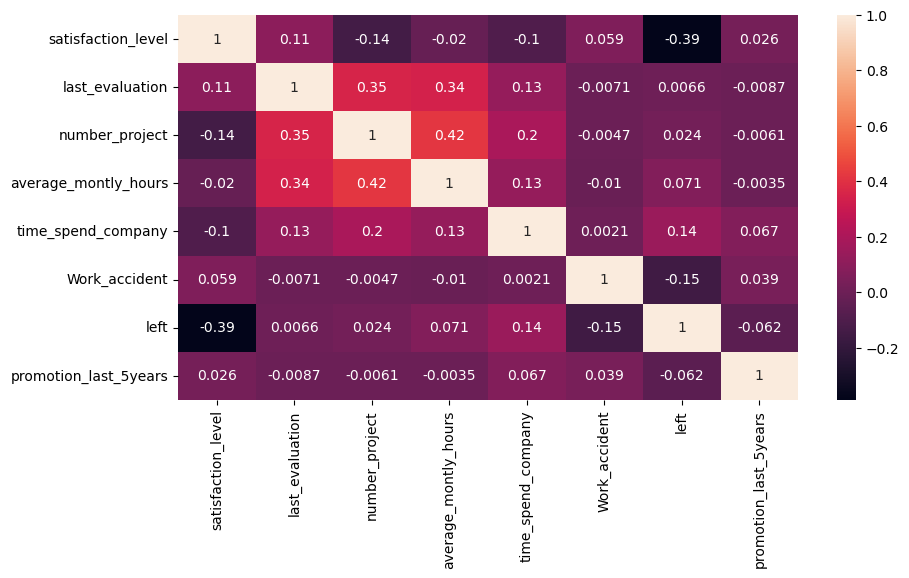

In [122]:
plt.figure(figsize=(10,5))
sns.heatmap(emp_data.iloc[:,0:8].corr(), annot=True)
plt.show()

#### 2.2 Draw the distribution plot of:

Employee Satisfaction (use column satisfaction_level)

<Figure size 1000x500 with 0 Axes>

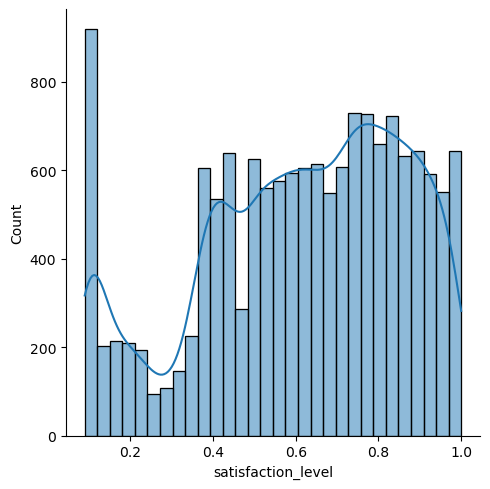

In [123]:
plt.figure(figsize=(10,5))
sns.displot(emp_data['satisfaction_level'], kde=True)
plt.show()


Employee Evaluation (use column last_evaluation)

<Figure size 1000x500 with 0 Axes>

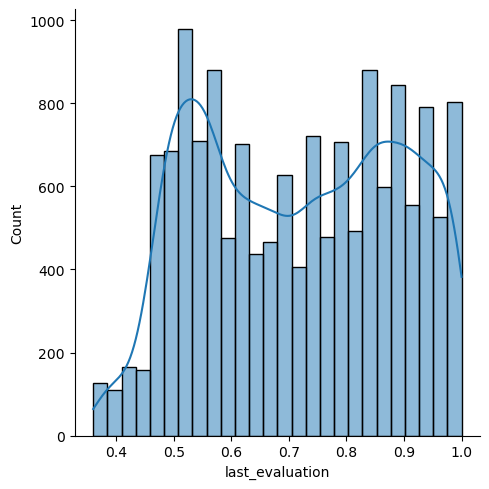

In [124]:
plt.figure(figsize=(10,5))
sns.displot(emp_data['last_evaluation'], kde=True)
plt.show()


Employee Average Monthly Hours (use column average_montly_hours)

<Figure size 1000x500 with 0 Axes>

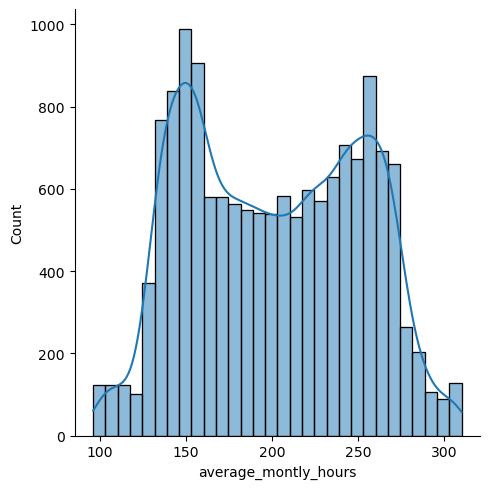

In [125]:
plt.figure(figsize=(10,5))
sns.displot(emp_data['average_montly_hours'], kde=True)
plt.show()

#### 2.3 Draw the bar plot of the employee project count of both employees who left and stayed in the organization (use column number_project and hue column left), and give your inferences from the plot.

In [126]:
emp_data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [127]:
emp_project_left = emp_data.groupby(['number_project','left'])['number_project'].count().reset_index(name='employee_count')
emp_project_left

,number_project,left,employee_count
0,2,0,821
1,2,1,1567
2,3,0,3983
3,3,1,72
4,4,0,3956
5,4,1,409
6,5,0,2149
7,5,1,612
8,6,0,519
9,6,1,655


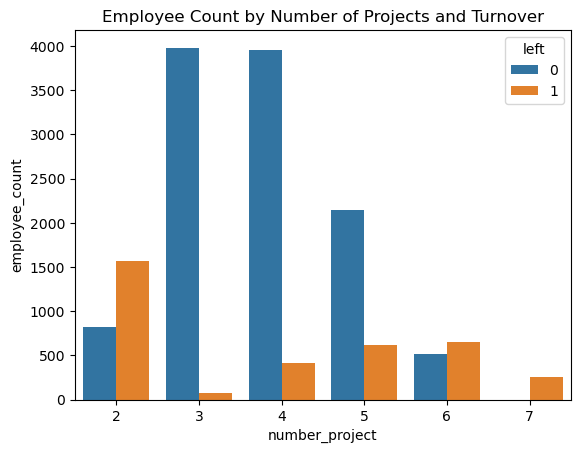

In [128]:
sns.barplot(x='number_project', y='employee_count',hue='left', data=emp_project_left)
plt.title('Employee Count by Number of Projects and Turnover')
plt.show()

#### Observations:

- Employees who is having 5 to 7 project count and heavy work load and high turnover rate.
- Employees who is having 3 - 4 project count is medium work load and low turnover rate.
- Employees who is having 2 project count who is having less work load and high turnover rate.

Optimal project count to low turnover rate is 3 to 4 projects. Suggested for good work life balance.

### 3. Perform clustering of employees who left based on their satisfaction and evaluation.

#### 3.1 Choose columns satisfaction_level, last_evaluation, and left.

In [129]:
emp_data_left = emp_data[emp_data['left']==1][['satisfaction_level','last_evaluation']]
emp_data_left

,satisfaction_level,last_evaluation
0,0.38,0.53
1,0.80,0.86
2,0.11,0.88
3,0.72,0.87
4,0.37,0.52
...,...,...
14994,0.40,0.57
14995,0.37,0.48
14996,0.37,0.53
14997,0.11,0.96


#### 3.2 Do K-means clustering of employees who left the company into 3 clusters?

In [130]:
kmeans = KMeans(n_clusters=3,random_state=42)

In [131]:
kmeans.fit(emp_data_left)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [132]:
kmeans.inertia_

27.007707973602802

In [133]:
kmeans.cluster_centers_

array([[0.41014545, 0.51698182],
       [0.80851586, 0.91170931],
       [0.11115466, 0.86930085]])

In [134]:
kmeans.labels_

array([0, 1, 2, ..., 0, 2, 0], shape=(3571,), dtype=int32)

In [135]:
emp_data_left['cluster'] = kmeans.labels_

In [136]:
emp_data_left

,satisfaction_level,last_evaluation,cluster
0,0.38,0.53,0
1,0.80,0.86,1
2,0.11,0.88,2
3,0.72,0.87,1
4,0.37,0.52,0
...,...,...,...
14994,0.40,0.57,0
14995,0.37,0.48,0
14996,0.37,0.53,0
14997,0.11,0.96,2


#### 3.4 Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.

In [137]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['satisfaction_level', 'last_evaluation'])
centers

,satisfaction_level,last_evaluation
0,0.410145,0.516982
1,0.808516,0.911709
2,0.111155,0.869301


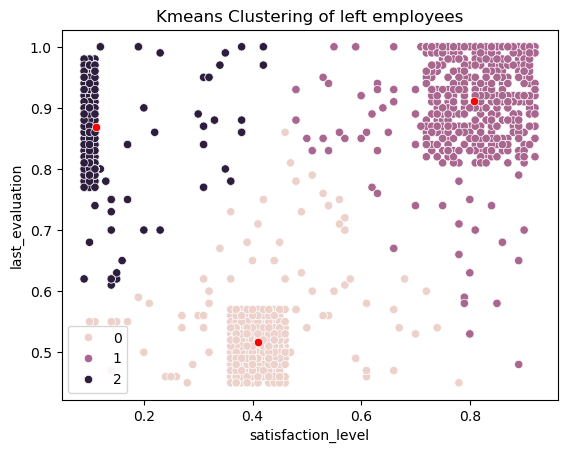

In [138]:
sns.scatterplot(data = emp_data_left, x = 'satisfaction_level' , y = 'last_evaluation' , hue = kmeans.labels_)
sns.scatterplot(x = centers['satisfaction_level'], y = centers['last_evaluation'] , color = 'red')
plt.title('Kmeans Clustering of left employees')
plt.show()

##### Observation

    Cluster 0:

        Moderate Satisfaction, Moderate Evaluation
        These employees are generally dissatisfied from their jobs.
        They have a least evaluation.
        They left the company might be because of dissatisfaction or poor ratings & feedback from manager.
        
        Based on above points, HR can take some action to maintain positive environment.

    Cluster 1:

        High Satisfaction, High Evaluation
        They are fully satisfied with their roles and tasks
        They are seems top performers.
        They might left due to some personal causes or might be they are holding offers from other company

    Cluster 2:

        Low Satisfaction, High Evaluation
        They are seems top performers.
        These employees are also one of the top performers but are unsatisfied with their current roles and assignments.
        They left might be due they are not getting promotions, lack of recognition in the company or no career growth option
        
        Based on above points, HR and project team may start upskilling employees by conducting training programs. Can initiate Rewards and Recognition programs.
     

### 4. Handle the left Class Imbalance using the SMOTE technique.

#### 4.1 Pre-process the data by converting categorical columns to numerical columns by:

Separating categorical variables and numeric variables

Applying get_dummies() to the categorical variables

Combining categorical variables and numeric variables

In [139]:
emp_data = pd.get_dummies(emp_data, columns=['salary','sales'], drop_first = True)
emp_data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary_low,salary_medium,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical
0,0.38,0.53,2,157,3,0,1,0,True,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,False,True,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,False,True,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,True,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,True,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,True,False,False,False,False,False,False,False,False,True,False
14995,0.37,0.48,2,160,3,0,1,0,True,False,False,False,False,False,False,False,False,True,False
14996,0.37,0.53,2,143,3,0,1,0,True,False,False,False,False,False,False,False,False,True,False
14997,0.11,0.96,6,280,4,0,1,0,True,False,False,False,False,False,False,False,False,True,False


In [140]:
emp_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   salary_low             14999 non-null  bool   
 9   salary_medium          14999 non-null  bool   
 10  sales_RandD            14999 non-null  bool   
 11  sales_accounting       14999 non-null  bool   
 12  sales_hr               14999 non-null  bool   
 13  sales_management       14999 non-null  bool   
 14  sales_marketing        14999 non-null  bool   
 15  sales_product

#### 4.2 Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.

In [141]:
x = emp_data.drop(['left'], axis=1)
y = emp_data['left']

In [142]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=20,random_state=123)

#### 4.3 Upsample the train dataset using the SMOTE technique from the imblearn module.

In [143]:
emp_data['left'].value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

In [144]:
smt = SMOTE(sampling_strategy='minority')
x_train_rs, y_train_rs = smt.fit_resample(x_train, y_train)

In [145]:
y_train_rs.value_counts()

left
0    11412
1    11412
Name: count, dtype: int64

### 5. Perform 5-fold cross-validation model training and evaluate performance

#### 5.1 Train a logistic regression model, apply a 5-fold CV, and plot the classification report.

In [146]:
logistic_model = LogisticRegression()
logistic_model.fit(x_train_rs,y_train_rs)
y_pred_lom = logistic_model.predict(x_test)

In [147]:
cv_score_lom = cross_val_score(LogisticRegression(), x_train_rs, y_train_rs, cv=5)
print(cv_score_lom)
print(np.mean(cv_score_lom))

[0.74107338 0.76122673 0.81007667 0.78751369 0.7971078 ]
0.7793996542300186


In [148]:
cr_lom = classification_report(y_test, y_pred_lom)
print("Classification Report of Logistic Model : ")
print(cr_lom)

Classification Report of Logistic Model : 
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        16
           1       1.00      0.50      0.67         4

    accuracy                           0.90        20
   macro avg       0.94      0.75      0.80        20
weighted avg       0.91      0.90      0.89        20



#### 5.2 Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.

In [149]:
random_forest = RandomForestClassifier()
random_forest.fit(x_train_rs,y_train_rs)
y_pred_rfc = random_forest.predict(x_test)

In [150]:
cv_score_rfc = cross_val_score(RandomForestClassifier(), x_train_rs, y_train_rs, cv=5)
print(cv_score_rfc)
print(np.mean(cv_score_rfc))

[0.98313253 0.98598028 0.9864184  0.98598028 0.98575811]
0.9854539214942794


In [151]:
cr_rfc = classification_report(y_test, y_pred_rfc)
print("Classification Report of Random Forest Classifier : ")
print(cr_rfc)

Classification Report of Random Forest Classifier : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         4

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



#### 5.3 Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.

In [152]:
gradient_boosting = GradientBoostingClassifier()
gradient_boosting.fit(x_train_rs,y_train_rs)
y_pred_gbc = gradient_boosting.predict(x_test)

In [153]:
cv_score_gbc = cross_val_score(GradientBoostingClassifier(), x_train_rs, y_train_rs, cv=5)
print(cv_score_gbc)
print(np.mean(cv_score_gbc))

[0.95596933 0.9618839  0.96254107 0.9686747  0.96209465]
0.9622327314196631


In [154]:
cr_gbc = classification_report(y_test, y_pred_gbc)
print("Classification Report of Gradient Boosting Classifier : ")
print(cr_gbc)

Classification Report of Gradient Boosting Classifier : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         4

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



### 6. Identify the best model and justify the evaluation metrics used.

#### 6.1 Find the ROC/AUC for each model and plot the ROC curve.

In [155]:
models_df = pd.DataFrame({'Test': y_test, 'Logistic': y_pred_lom, 'RandomForest': y_pred_rfc, 'GradientBoost': y_pred_gbc})
models_df

,Test,Logistic,RandomForest,GradientBoost
6958,0,0,0,0
7534,0,0,0,0
2975,0,0,0,0
3903,0,0,0,0
8437,0,0,0,0
6812,0,0,0,0
1567,1,1,1,1
14679,1,0,1,1
10188,0,0,0,0
11718,0,0,0,0


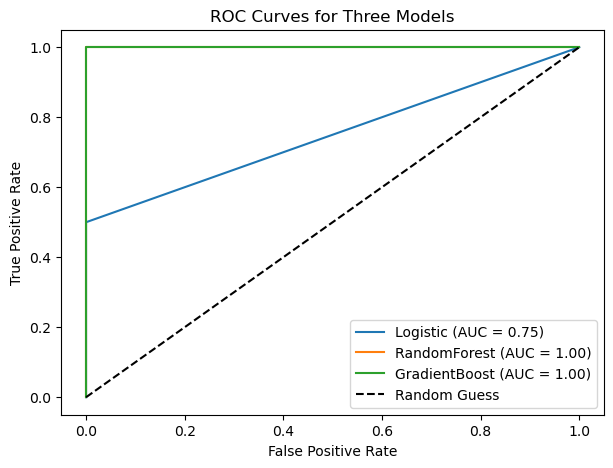

In [156]:
# Plotting ROC curve
plt.figure(figsize=(7, 5))

for model in ['Logistic', 'RandomForest', 'GradientBoost']:
    fpr, tpr, _ = roc_curve(models_df['Test'], models_df[model])
    auc = roc_auc_score(models_df['Test'], models_df[model])
    plt.plot(fpr, tpr, label=f'{model} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Three Models')
plt.legend()
plt.show()

#### 6.2 Find the confusion matrix for each of the models.

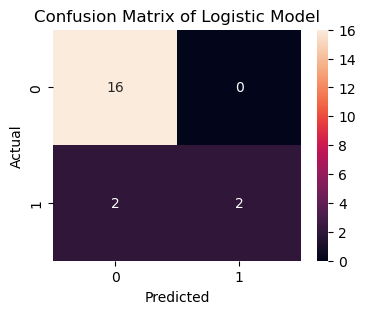

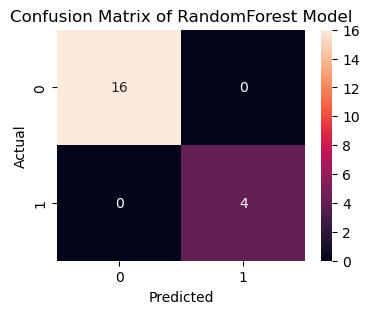

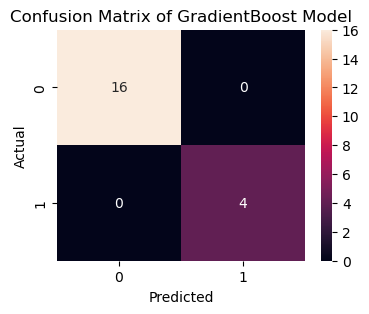

In [159]:
for model in ['Logistic', 'RandomForest', 'GradientBoost']:
  cm = confusion_matrix(models_df['Test'], models_df[model])
  plt.figure(figsize=(4,3))
  sns.heatmap(cm, annot=True, fmt='d')
  plt.title('Confusion Matrix of ' + model + ' Model')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

#### 6.3 Explain which metric needs to be used from the confusion matrix: Recall or Precision?

Recall is more useful. 
</br>
</br> Failing to identify employees who are leaving company is more critical.
</br> So Recall should be useful over precision.
</br>High recall ensures that the majority of employees who are likely to leave are identified.

### 7. Suggest various retention strategies for targeted employees.

#### 7.1 Using the best model, predict the probability of employee turnover in the test data.

In [166]:
# from Randomforest classifier model already got the predicted y
rfc_test_data = x_test.copy()
rfc_test_data['prob_of_leaving'] = y_pred_rfc
rfc_test_data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary_low,salary_medium,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,prob_of_leaving
6958,0.54,0.67,3,154,2,0,0,False,False,False,False,False,False,False,False,True,False,False,0
7534,0.72,0.52,3,143,4,1,0,True,False,False,False,False,False,False,False,False,True,False,0
2975,0.95,0.61,3,267,2,0,0,True,False,True,False,False,False,False,False,False,False,False,0
3903,0.78,0.79,3,203,2,0,0,True,False,False,False,False,False,False,False,True,False,False,0
8437,0.60,0.40,3,146,4,1,0,True,False,False,False,False,False,False,False,False,False,True,0
6812,0.78,0.65,3,157,2,0,0,True,False,False,False,False,False,False,False,True,False,False,0
1567,0.40,0.48,2,132,3,0,0,True,False,False,False,False,False,False,False,False,False,True,1
14679,0.90,0.92,5,245,5,0,0,True,False,False,False,False,False,False,False,True,False,False,1
10188,0.87,0.49,4,213,3,0,0,True,False,False,False,False,False,False,False,False,False,True,0
11718,0.63,0.85,4,182,3,1,0,False,False,False,False,False,False,False,False,True,False,False,0


#### 7.2 Based on the probability score range below, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone.

Safe Zone (Green) (Score < 20%)

Low-Risk Zone (Yellow) (20% < Score < 60%)

Medium-Risk Zone (Orange) (60% < Score < 90%)

High-Risk Zone (Red) (Score > 90%).



In [167]:
rfc_test_data['Zone'] = pd.cut(rfc_test_data['prob_of_leaving'], bins=[0.0, 0.2, 0.6, 0.9, 1], labels=['Green-Safe', 'Yellow-LowRisk', 'Orange-MediumRisk', 'Red-HighRisk'], include_lowest
=True)
rfc_test_data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary_low,salary_medium,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,prob_of_leaving,Zone
6958,0.54,0.67,3,154,2,0,0,False,False,False,False,False,False,False,False,True,False,False,0,Green-Safe
7534,0.72,0.52,3,143,4,1,0,True,False,False,False,False,False,False,False,False,True,False,0,Green-Safe
2975,0.95,0.61,3,267,2,0,0,True,False,True,False,False,False,False,False,False,False,False,0,Green-Safe
3903,0.78,0.79,3,203,2,0,0,True,False,False,False,False,False,False,False,True,False,False,0,Green-Safe
8437,0.60,0.40,3,146,4,1,0,True,False,False,False,False,False,False,False,False,False,True,0,Green-Safe
6812,0.78,0.65,3,157,2,0,0,True,False,False,False,False,False,False,False,True,False,False,0,Green-Safe
1567,0.40,0.48,2,132,3,0,0,True,False,False,False,False,False,False,False,False,False,True,1,Red-HighRisk
14679,0.90,0.92,5,245,5,0,0,True,False,False,False,False,False,False,False,True,False,False,1,Red-HighRisk
10188,0.87,0.49,4,213,3,0,0,True,False,False,False,False,False,False,False,False,False,True,0,Green-Safe
11718,0.63,0.85,4,182,3,1,0,False,False,False,False,False,False,False,False,True,False,False,0,Green-Safe


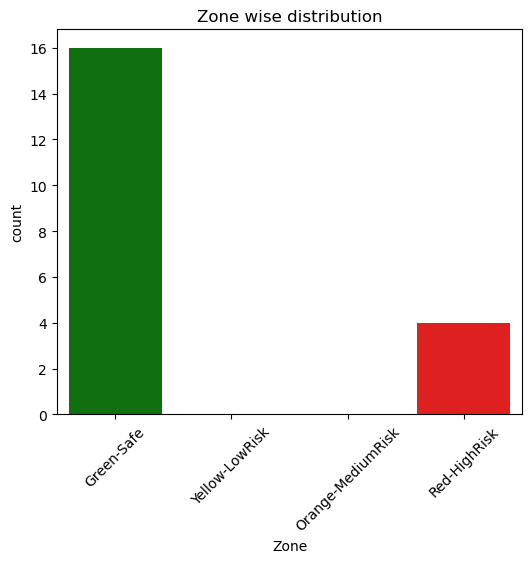

In [168]:
plt.figure(figsize=(6,5))
sns.countplot(x='Zone', data=rfc_test_data, palette=['Green', 'Yellow', 'Orange', 'Red'])
plt.title('Zone wise distribution')
plt.xticks(rotation=45)
plt.show()

#### Observations

HR can continue existing policies, as employees are in their most comfortable zone. </br> 
Low-Risk Zone: HR can work on starting quarterly rewards or recognition programmes to motivate employees. </br> 
Medium-Risk Zone: HR can conduct training programmes to upskill employees into their area of interest. and can assign challenging roles as per their experience. </br>
High-Risk Zone: HR can offer target-based designation promotion and can have one-on-one talks with employees to discuss their expectations.